# 04 — Statistical base models: seasonal naive and ETS

- **ETS:** additive trend and additive 24-hour seasonality, estimated initial states, no Box–Cox transformation, daily refitting on expanding history.
- **Seasonal naive:** copy the published price curve for the preceding local calendar day. Exclude a forecast when that preceding day has 23 or 25 hours; do not silently substitute an elapsed-24-hour lag.
- **2017:** start with 2015–2016 history; export forecasts for downstream model ranking and stacking.
- **2018:** start with 2015–2017 history; export forecasts for final evaluation. Do not use 2018 results to choose models or settings.

For each delivery day D, issue all 24 predictions together at 11:00 local time on D−1. The complete D−1 day-ahead price curve is already published then. History ends immediately before D starts; no D target price enters fitting. Earlier delivery days within the forecast year become available for subsequent daily refits. This preserves the source notebook's rolling-origin procedure; it differs from the fixed annual ML/DL refits in Notebook 3.

### Inputs and execution

- Notebook 1: `data/processed/energy_dataset_clean.csv`, preserving the continuous history, including DST days.
- Notebook 2: `data/features/day_ahead_features.npz`, `sample_metadata.csv`, `target_timestamps.csv`, and `feature_manifest.json`, defining eligible samples and target alignment.
- Optional Notebook 3 forecasts: `outputs/base_models/base_predictions_2017.csv` and `base_predictions_2018.csv`.

### Outputs

`outputs/statistical_models/` contains `base_predictions_YEAR.csv` (`time`, `y_true`, `ETS_day`, `Naive_day`), individual/common-sample metric tables, daily fit audits, naive exclusions and a reproducibility manifest. Rows follow Notebook 2 exactly; Naive_day is missing on its explicitly excluded days.

If Notebook 3 outputs exist, `outputs/combined_base_models/` receives the combined base predictions and metrics, plus complete-case prediction files for stacking. Source files are not overwritten. Alternatively, set Notebook 3's `STATISTICAL_DIR` to `PROJECT_ROOT / 'outputs' / 'statistical_models'` before running its optional merge.


In [1]:
from pathlib import Path
from functools import lru_cache
import hashlib
import json
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
FEATURE_DIR = PROJECT_ROOT / 'data' / 'features'
PRICE_FILE = PROJECT_ROOT / 'data' / 'processed' / 'energy_dataset_clean.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'statistical_models'
ML_DL_DIR = PROJECT_ROOT / 'outputs' / 'base_models'
COMBINED_DIR = PROJECT_ROOT / 'outputs' / 'combined_base_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Prespecified source-notebook settings; do not select these using 2018 results.
ETS_SETTINGS = {'seasonal_periods': 24, 'trend': 'add', 'seasonal': 'add',
                'initialization_method': 'estimated', 'use_boxcox': False}
ROLLING_WINDOW = None  # None preserves expanding history; integer means elapsed hours.
WINDOWS = {2017: [2015, 2016], 2018: [2015, 2016, 2017]}
MODEL_NAMES = ['ETS_day', 'Naive_day']


## 1. Load the common samples and continuous price history

Do not rebuild features or infer eligibility from the cleaned series. Validate Notebook 2's sample IDs, delivery years, forecast origins and horizon timestamps, then check that its targets agree with Notebook 1's cleaned prices. Read prices in UTC and convert to the manifest timezone to retain distinct DST timestamps.


In [3]:
input_paths = [PRICE_FILE] + [FEATURE_DIR / name for name in
    ['day_ahead_features.npz', 'sample_metadata.csv', 'target_timestamps.csv', 'feature_manifest.json']]

for path in input_paths:
    if not path.is_file():
        raise FileNotFoundError(f'Missing {path}. Run Notebooks 1 and 2 or correct PROJECT_ROOT.')

manifest = json.loads((FEATURE_DIR / 'feature_manifest.json').read_text())
TIMEZONE = manifest['timezone']
TARGET = manifest['target']
HORIZON = int(manifest['forecast_horizon'])

if HORIZON != 24 or manifest['forecast_origin_local_hour'] != 11:
    raise ValueError('Expected the Notebook 2 protocol: 24 delivery hours, 11:00 origin.')

metadata = pd.read_csv(FEATURE_DIR / 'sample_metadata.csv')
timestamps = pd.read_csv(FEATURE_DIR / 'target_timestamps.csv').sort_values(['sample_id', 'horizon'])
with np.load(FEATURE_DIR / 'day_ahead_features.npz', allow_pickle=False) as archive:
    targets = archive['y'].copy()

n = len(metadata)
if targets.shape != (n, HORIZON) or list(targets.shape) != manifest['target_shape'] or not np.isfinite(targets).all():
    raise ValueError('Invalid target array.')
if not np.array_equal(metadata.sample_id, np.arange(n)):
    raise ValueError('Sample metadata must match array row order.')
if not np.array_equal(timestamps.sample_id, np.repeat(np.arange(n), HORIZON)):
    raise ValueError('Missing or duplicate timestamp sample IDs.')
if not np.array_equal(timestamps.horizon, np.tile(np.arange(1, HORIZON + 1), n)):
    raise ValueError('Expected horizons 1–24 for each sample.')

days = pd.DatetimeIndex(pd.to_datetime(metadata.delivery_day)).tz_localize(TIMEZONE)
if not days.is_unique or not days.is_monotonic_increasing:
    raise ValueError('Delivery days must be unique and chronological.')

if not np.array_equal(days.year, metadata.delivery_year) or set(days.year) != {2015, 2016, 2017, 2018}:
    raise ValueError('Invalid delivery-year metadata.')
target_index = pd.DatetimeIndex(pd.to_datetime(timestamps.target_timestamp, utc=True)).tz_convert(TIMEZONE)

if not target_index.is_unique or not target_index.is_monotonic_increasing:
    raise ValueError('Target timestamps must be unique and chronological.')

if not np.array_equal(target_index.normalize().asi8, np.repeat(days.asi8, HORIZON)):
    raise ValueError('Target timestamps do not match sample delivery days.')

if not np.array_equal(target_index.hour, np.tile(np.arange(HORIZON), n)):
    raise ValueError('Expected local delivery hours 00–23.')

if not np.array_equal(timestamps.delivery_day, np.repeat(metadata.delivery_day, HORIZON)):
    raise ValueError('Inconsistent delivery-day labels.')
origins = pd.DatetimeIndex(pd.to_datetime(metadata.forecast_origin, utc=True)).tz_convert(TIMEZONE)
expected_origins = (days.tz_localize(None) - pd.Timedelta(days=1) + pd.Timedelta(hours=11)).tz_localize(TIMEZONE)

if not origins.equals(expected_origins):
    raise ValueError('Expected 11:00 local time on D−1.')
history_ends = pd.DatetimeIndex(pd.to_datetime(metadata.price_history_end, utc=True)).tz_convert(TIMEZONE)

if not np.array_equal(history_ends.asi8, target_index[::HORIZON].asi8 - pd.Timedelta(hours=1).value):
    raise ValueError('Invalid price-history endpoints.')

raw = pd.read_csv(PRICE_FILE, usecols=['time', TARGET])
price_index = pd.DatetimeIndex(pd.to_datetime(raw.time, utc=True)).tz_convert(TIMEZONE)
prices = pd.Series(raw[TARGET].to_numpy(dtype=float), index=price_index, name=TARGET).sort_index()

if not prices.index.is_unique or not np.isfinite(prices).all():
    raise ValueError('Cleaned prices must be unique and finite.')
if not np.all(np.diff(prices.index.asi8) == pd.Timedelta(hours=1).value):
    raise ValueError('Price history must be continuous in elapsed hourly time.')
if not np.allclose(prices.reindex(target_index), targets.ravel(), rtol=1e-5, atol=1e-4):
    raise ValueError('Notebook 1 prices and Notebook 2 targets do not agree.')

training_targets = pd.Series(targets.ravel().astype(float), index=target_index)
display(metadata.groupby('delivery_year').size().rename('eligible_days'))


delivery_year
2015    355
2016    364
2017    363
2018    363
Name: eligible_days, dtype: int64

## 2. Training-only descriptive view

Exploratory plots are restricted to 2015.  


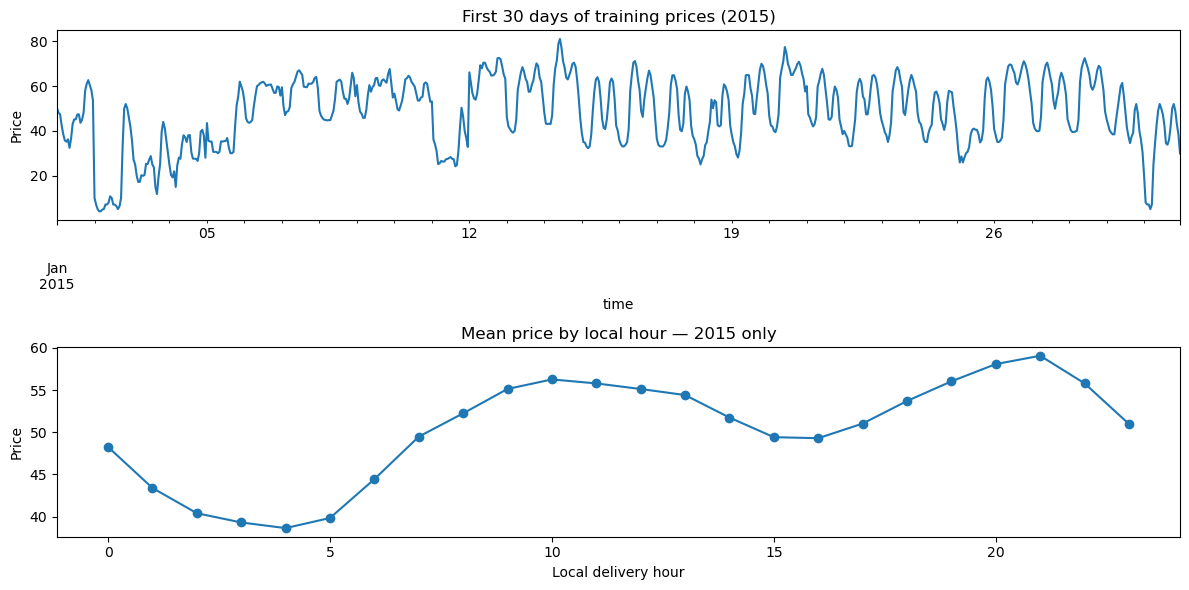

In [5]:
diagnostic = prices.loc[prices.index.year == 2015]
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
diagnostic.iloc[:24 * 30].plot(ax=axes[0], title='First 30 days of training prices (2015)')
diagnostic.groupby(diagnostic.index.hour).mean().plot(ax=axes[1], marker='o', title='Mean price by local hour — 2015 only')
axes[1].set_xlabel('Local delivery hour')
for ax in axes:
    ax.set_ylabel('Price')
plt.tight_layout()
plt.show()


## 3. Daily forecasting functions

ETS uses a positional hourly array so its period of 24 means **24 elapsed hours**, preserving the source model even around DST. Each fit receives only history through the saved `price_history_end`. Convergence failures stop execution rather than silently producing forecasts; nonfatal optimizer warnings are retained in the daily audit. Seasonal naive uses a local calendar-day slice, so it intentionally has a different DST rule.

No forecast-day observations update the model within its 24-step forecast. Earlier forecast-year prices enter later fits only once their published delivery curve is available.


In [8]:
def forecast_ets(history, settings=ETS_SETTINGS):
    values = history.to_numpy(dtype=float)
    if len(values) < 2 * settings['seasonal_periods'] or not np.isfinite(values).all():
        raise ValueError('ETS requires at least two complete seasonal cycles of finite history.')
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        result = ExponentialSmoothing(values, **settings).fit(optimized=True)
        forecast = np.asarray(result.forecast(HORIZON), dtype=float).reshape(-1)
    optimizer = getattr(result, 'mle_retvals', None)
    success = optimizer.get('success', None) if optimizer is not None else None
    if success is not None and not bool(success):
        raise RuntimeError(f'ETS optimizer failed: {optimizer}')
    if forecast.shape != (HORIZON,) or not np.isfinite(forecast).all():
        raise ValueError('Invalid ETS forecast.')
    return forecast, {'runtime_seconds': time.perf_counter() - started,
                      'optimizer_success': None if success is None else bool(success),
                      'warnings': ' | '.join(str(item.message) for item in captured)}


def forecast_calendar_naive(history, delivery_day):
    previous_day = delivery_day - pd.DateOffset(days=1)
    previous = history.loc[history.index.normalize() == previous_day]
    if len(previous) != HORIZON:
        return np.full(HORIZON, np.nan), len(previous)
    if not np.array_equal(previous.index.hour, np.arange(HORIZON)):
        raise ValueError('Preceding calendar-day hours are not 00–23.')
    return previous.to_numpy(dtype=float), len(previous)


def forecast_year(test_year):
    train_years = WINDOWS[test_year]
    initial_start = pd.Timestamp(year=min(train_years), month=1, day=1, tz=TIMEZONE)
    positions = np.flatnonzero(metadata.delivery_year.eq(test_year).to_numpy())
    if not len(positions):
        raise ValueError(f'No samples for {test_year}.')
    forecasts, audits, exclusions = [], [], []
    for number, pos in enumerate(positions, start=1):
        day = days[pos]
        idx = target_index[pos * HORIZON:(pos + 1) * HORIZON]
        history = prices.loc[initial_start:history_ends[pos]]
        if history.empty or history.index[-1] != history_ends[pos] or history.index[-1] >= idx[0]:
            raise ValueError(f'Incorrect history endpoint for {day}.')
        ets_history = history if ROLLING_WINDOW is None else history.iloc[-ROLLING_WINDOW:]
        try:
            ets, audit = forecast_ets(ets_history)
        except Exception as error:
            raise RuntimeError(f'ETS failed for delivery day {day.date()}: {error}') from error
        naive, previous_hours = forecast_calendar_naive(history, day)
        if previous_hours != HORIZON:
            exclusions.append({'delivery_day': str(day.date()), 'year': test_year,
                               'previous_day_hours': previous_hours,
                               'reason': 'previous_calendar_day_not_24_hours'})
        forecasts.append(pd.DataFrame({'y_true': targets[pos], 'ETS_day': ets,
                                       'Naive_day': naive}, index=idx))
        audits.append({'delivery_day': str(day.date()), 'forecast_origin': origins[pos].isoformat(),
                       'history_start': ets_history.index[0].isoformat(),
                       'history_end': ets_history.index[-1].isoformat(),
                       'history_hours': len(ets_history), **audit})
        if number == 1 or number % 30 == 0 or number == len(positions):
            print(f'{test_year}: {number}/{len(positions)} eligible days forecast')
    frame = pd.concat(forecasts)
    if len(frame) != len(positions) * HORIZON or not frame.index.is_unique:
        raise ValueError('Forecast output alignment failed.')
    audit_frame = pd.DataFrame(audits)
    excluded_frame = pd.DataFrame(exclusions, columns=['delivery_day', 'year', 'previous_day_hours', 'reason'])
    frame.to_csv(OUTPUT_DIR / f'base_predictions_{test_year}.csv', index_label='time')
    audit_frame.to_csv(OUTPUT_DIR / f'ets_fit_audit_{test_year}.csv', index=False)
    excluded_frame.to_csv(OUTPUT_DIR / f'naive_excluded_days_{test_year}.csv', index=False)
    return frame, audit_frame, excluded_frame


## 4. Metrics on individual and common eligible days

Compute MAE, RMSE, MAPE, R² and MASE on complete 24-hour days. Individual coverage and common coverage are exported separately; compare models using the common table. Metrics pool all horizons without intermediate rounding.

For compatibility with Notebook 3, MASE uses only Notebook 2 targets in the applicable initial training years, paired with observations exactly 24 elapsed hours earlier. Missing pairs, including excluded DST days, are omitted. The denominator remains fixed throughout each forecast year. This differs slightly from the source statistical notebook's full continuous training-series denominator. MAPE clips absolute target prices at 1e-6 and can be very large near zero.


In [10]:
@lru_cache(maxsize=None)
def mase_scale(years):
    history = training_targets.loc[training_targets.index.year.isin(years)]
    previous = history.reindex(history.index - pd.Timedelta(hours=24)).to_numpy()
    valid = np.isfinite(previous)
    scale = np.mean(np.abs(history.to_numpy()[valid] - previous[valid])) if valid.any() else np.nan
    if not np.isfinite(scale) or scale <= 0:
        raise ValueError(f'Undefined MASE scale for {years}.')
    return float(scale)


def metrics(actual, predicted, train_years):
    actual, predicted = np.asarray(actual, dtype=float), np.asarray(predicted, dtype=float)
    if actual.shape != predicted.shape or not actual.size or not np.isfinite([actual, predicted]).all():
        raise ValueError('Metrics require matching, finite, non-empty arrays.')
    errors = actual - predicted
    mae = np.mean(np.abs(errors))
    sse = np.sum(errors ** 2)
    sst = np.sum((actual - actual.mean()) ** 2)
    r2 = 1.0 - sse / sst if sst > 0 else (1.0 if sse == 0 else 0.0)
    return {'MAE': mae, 'RMSE': np.sqrt(np.mean(errors ** 2)),
            'MAPE': 100 * np.mean(np.abs(errors) / np.clip(np.abs(actual), 1e-6, None)),
            'R2': r2, 'MASE': mae / mase_scale(tuple(train_years))}


def complete_day_mask(frame, columns):
    valid = pd.Series(np.isfinite(frame[['y_true', *columns]].to_numpy(dtype=float)).all(axis=1), index=frame.index)
    counts = valid.groupby(frame.index.normalize()).sum()
    complete_days = counts.index[counts.eq(HORIZON)]
    return valid & frame.index.normalize().isin(complete_days)


def evaluate_frame(frame, year, model_names):
    common = complete_day_mask(frame, model_names)
    rows = []
    for coverage in ['individual', 'common']:
        for name in model_names:
            keep = common if coverage == 'common' else complete_day_mask(frame, [name])
            if not keep.any():
                raise ValueError(f'No complete {coverage} days for {name} in {year}.')
            rows.append({'year': year, 'coverage': coverage, 'model': name,
                         'n_forecasts': int(keep.sum()), 'n_days': int(keep.sum() // HORIZON),
                         **metrics(frame.loc[keep, 'y_true'], frame.loc[keep, name], WINDOWS[year])})
    return pd.DataFrame(rows), common


## 5. Generate 2017 forecasts, then final 2018 forecasts

The configuration is fixed before either forecast year is evaluated. Each completed year's output is saved immediately. ETS fits are not resumed from the audit CSV; rerunning a year refits that year's days.


In [12]:
predictions = {}
for year in WINDOWS:
    predictions[year], fit_audit, naive_excluded = forecast_year(year)
    metric_table, common = evaluate_frame(predictions[year], year, MODEL_NAMES)
    metric_table.to_csv(OUTPUT_DIR / f'statistical_metrics_{year}.csv', index=False)
    metric_table.loc[metric_table.coverage.eq('common')].to_csv(OUTPUT_DIR / f'base_metrics_{year}.csv', index=False)
    print(f'{year}: {len(predictions[year])} eligible hours; {int(common.sum())} common valid hours')
    display(metric_table)
    display(naive_excluded)


2017: 1/363 eligible days forecast
2017: 30/363 eligible days forecast
2017: 60/363 eligible days forecast
2017: 90/363 eligible days forecast
2017: 120/363 eligible days forecast
2017: 150/363 eligible days forecast
2017: 180/363 eligible days forecast
2017: 210/363 eligible days forecast
2017: 240/363 eligible days forecast
2017: 270/363 eligible days forecast
2017: 300/363 eligible days forecast
2017: 330/363 eligible days forecast
2017: 360/363 eligible days forecast
2017: 363/363 eligible days forecast
2017: 8712 eligible hours; 8664 common valid hours


,year,coverage,model,n_forecasts,n_days,MAE,RMSE,MAPE,R2,MASE
0,2017,individual,ETS_day,8712,363,11.259011,14.731038,24.169036,-0.441162,1.371060
1,2017,individual,Naive_day,8664,361,7.293516,10.860758,16.735511,0.217625,0.888164
2,2017,common,ETS_day,8664,361,11.260642,14.734781,24.165889,-0.440064,1.371259
3,2017,common,Naive_day,8664,361,7.293516,10.860758,16.735511,0.217625,0.888164


,delivery_day,year,previous_day_hours,reason
0,2017-03-27,2017,23,previous_calendar_day_not_24_hours
1,2017-10-30,2017,25,previous_calendar_day_not_24_hours


2018: 1/363 eligible days forecast
2018: 30/363 eligible days forecast
2018: 60/363 eligible days forecast
2018: 90/363 eligible days forecast
2018: 120/363 eligible days forecast
2018: 150/363 eligible days forecast
2018: 180/363 eligible days forecast
2018: 210/363 eligible days forecast
2018: 240/363 eligible days forecast
2018: 270/363 eligible days forecast
2018: 300/363 eligible days forecast
2018: 330/363 eligible days forecast
2018: 360/363 eligible days forecast
2018: 363/363 eligible days forecast
2018: 8712 eligible hours; 8664 common valid hours


,year,coverage,model,n_forecasts,n_days,MAE,RMSE,MAPE,R2,MASE
0,2018,individual,ETS_day,8712,363,8.470006,11.339098,22.209157,0.215532,1.071651
1,2018,individual,Naive_day,8664,361,6.975585,10.411449,20.650103,0.339597,0.882572
2,2018,common,ETS_day,8664,361,8.485192,11.357721,22.270612,0.214097,1.073572
3,2018,common,Naive_day,8664,361,6.975585,10.411449,20.650103,0.339597,0.882572


,delivery_day,year,previous_day_hours,reason
0,2018-03-26,2018,23,previous_calendar_day_not_24_hours
1,2018-10-29,2018,25,previous_calendar_day_not_24_hours


## 6. Combine with Notebook 3 forecasts, when available

Align by timezone-aware timestamps, require identical eligible-hour coverage and target agreement, then retain the statistical missing-value flags. The separate `common_base_predictions_YEAR.csv` contains only days with 24 valid predictions from every model. Use its 2017 rows for stacking estimation and reserve 2018 for final evaluation. A missing ML/DL input only skips the optional merge.


In [14]:
def combine_with_ml_dl(year, statistical):
    path = ML_DL_DIR / f'base_predictions_{year}.csv'
    if not path.exists():
        print(f'No {path}; statistical outputs are complete, optional merge skipped.')
        return None
    ml = pd.read_csv(path)
    ml.index = pd.DatetimeIndex(pd.to_datetime(ml.pop('time'), utc=True)).tz_convert(TIMEZONE)
    if not ml.index.is_unique or len(ml) != len(statistical) or set(ml.index) != set(statistical.index):
        raise ValueError(f'Eligible timestamps differ in {path}.')
    ml = ml.reindex(statistical.index)
    if 'y_true' not in ml or not np.allclose(ml.y_true, statistical.y_true, rtol=1e-5, atol=1e-4):
        raise ValueError(f'Target mismatch in {path}.')
    if set(MODEL_NAMES).intersection(ml.columns):
        raise ValueError('ML/DL input already contains statistical model columns.')
    combined = ml.join(statistical[MODEL_NAMES])
    names = [name for name in combined if name != 'y_true']
    table, common = evaluate_frame(combined, year, names)
    COMBINED_DIR.mkdir(parents=True, exist_ok=True)
    combined.to_csv(COMBINED_DIR / f'base_predictions_{year}.csv', index_label='time')
    combined.loc[common].to_csv(COMBINED_DIR / f'common_base_predictions_{year}.csv', index_label='time')
    table.to_csv(COMBINED_DIR / f'coverage_metrics_{year}.csv', index=False)
    table.loc[table.coverage.eq('common')].to_csv(COMBINED_DIR / f'base_metrics_{year}.csv', index=False)
    print(year, 'common combined days:', int(common.sum() // HORIZON))
    return combined

combined_predictions = {year: combine_with_ml_dl(year, frame) for year, frame in predictions.items()}


2017 common combined days: 361
2018 common combined days: 361


## 7. Plot a fixed final-evaluation interval and save provenance

This December 2018 plot is descriptive after fitting, not a basis for changing model settings. Hashes identify the exact source files used; fit warnings and history endpoints are available in the daily audit files.


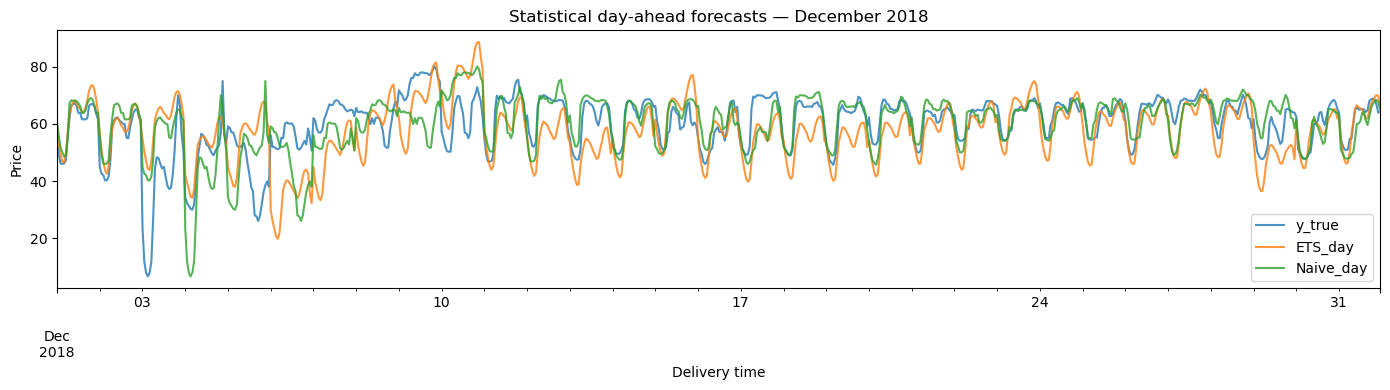

Statistical outputs: /Users/fatimarodrigues/Documents/Aulas/MINDD/Trabs-Pratico/2025-26/TP2-2025/git-price-forecasting/electricity-price-forecasting-revisão/initial-weather/outputs/statistical_models


In [16]:
frame = predictions[2018]
view = frame.loc[frame.index.month == 12]
ax = view.plot(figsize=(14, 4), title='Statistical day-ahead forecasts — December 2018', alpha=0.8)
ax.set_ylabel('Price')
ax.set_xlabel('Delivery time')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'statistical_forecasts_december_2018.png', dpi=160)
plt.show()

run_manifest = {
    'feature_manifest': manifest, 'ets_settings': ETS_SETTINGS,
    'rolling_window_hours': ROLLING_WINDOW, 'windows': WINDOWS,
    'naive_rule': 'Previous local calendar day; exclude when its length is not 24 hours',
    'mase_rule': 'Notebook 2 training-year targets paired at exactly 24 elapsed hours',
    'versions': {'python': platform.python_version(), 'numpy': np.__version__,
                 'pandas': pd.__version__, 'statsmodels': statsmodels.__version__},
    'input_sha256': {str(path.relative_to(PROJECT_ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
                     for path in input_paths},
}
(OUTPUT_DIR / 'run_manifest.json').write_text(json.dumps(run_manifest, indent=2))
print('Statistical outputs:', OUTPUT_DIR)
